In [6]:
import os
import numpy as np
import pandas as pd

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

from dekef.scorematching_penalized_grid_points import *
from dekef.scorematching_earlystopping_grid_points import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

from datetime import datetime as dt

from matplotlib import gridspec
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
waiting = waiting[waiting != 108.0]
# waiting = np.append(waiting, contam_pt)

bw = 5.
kernel_type = 'gaussian_poly2'

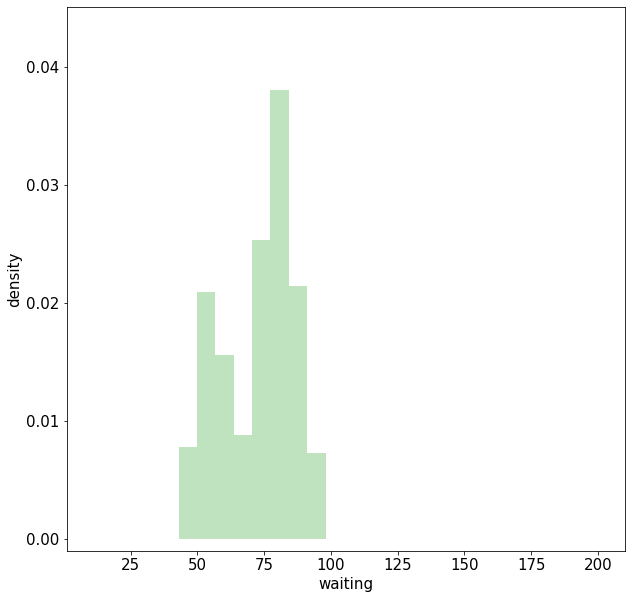

In [3]:
# set plot parameters
font_size = 15
xlimit = (1., 210.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0451)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)

# plt.savefig(f'../plots/histogram.pdf', bbox_inches = 'tight')

In [4]:
108 in waiting

False

In [62]:
base_density1 = BasedenGamma(waiting, 26., 3.)
base_density2 = BasedenGamma(waiting, 26., 2.5) 

In [32]:
bd = BasedenGamma(waiting)
bd.a, bd.scale

(25.531808661711896, 2.8276348075860365)

## Plots of base densities 

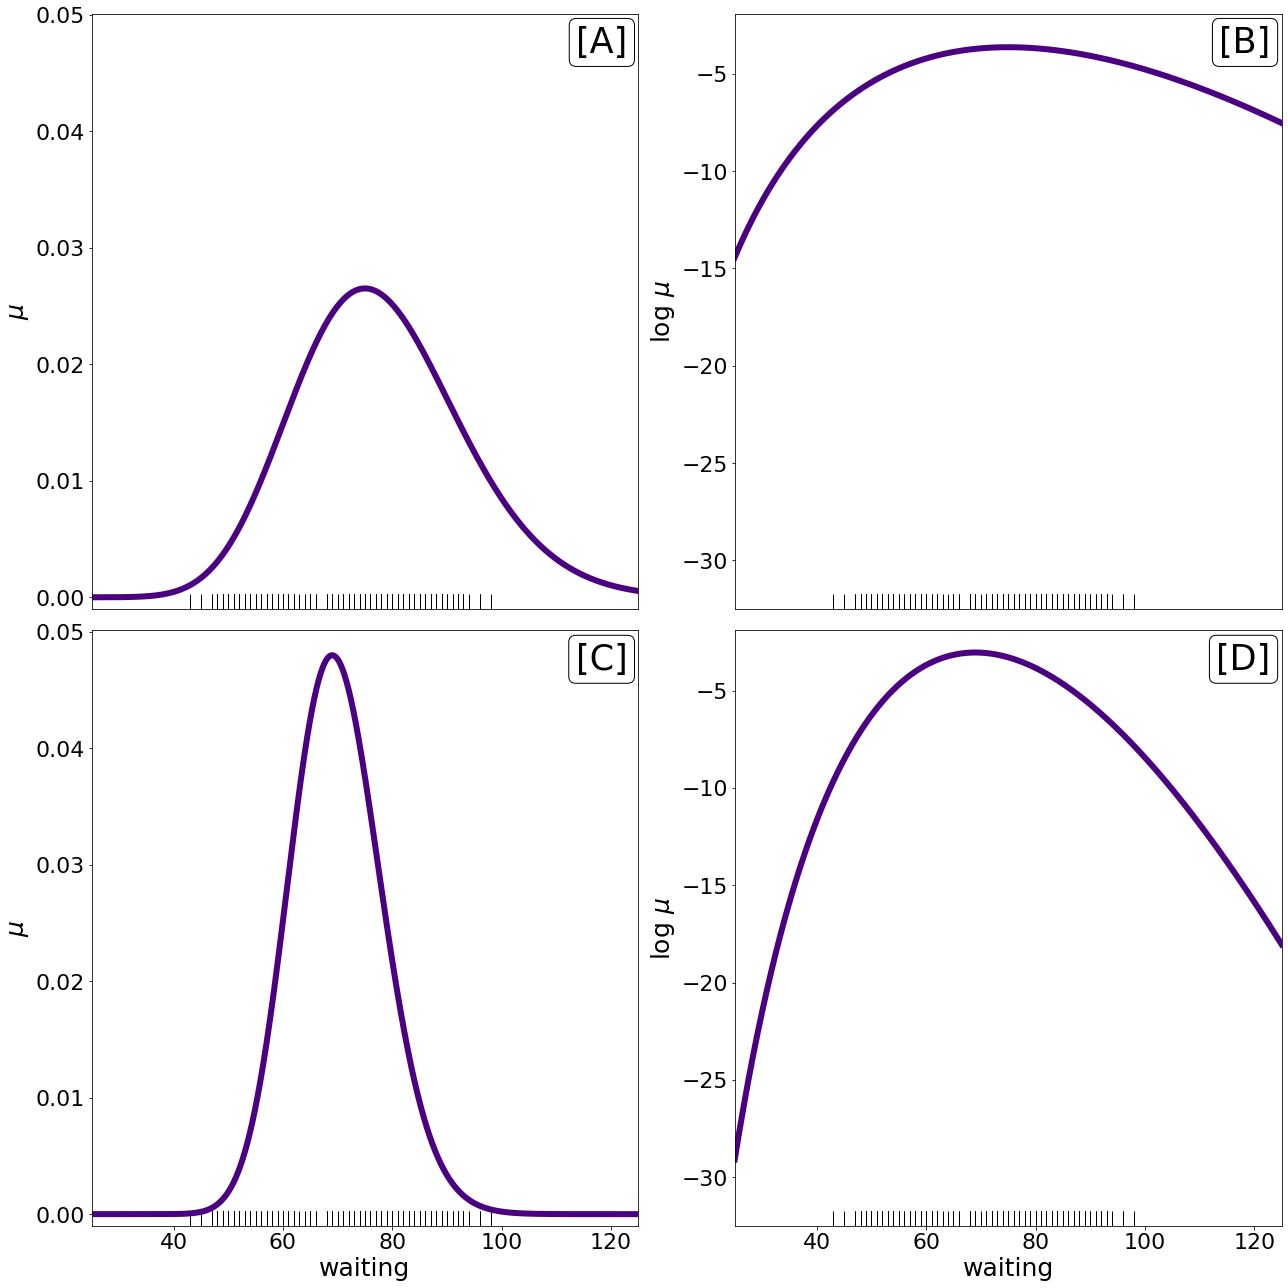

In [38]:
info_coord = (0.98, 0.98)
horizontalalignment, verticalalignment = 'right', 'top'
xticks = [40, 60, 80, 100, 120]

# set plot parameters
xlimit = (25., 125.)
den_limit = (-0.001, 0.0501)
logden_limit = (-32.5, -1.9)

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)
base_den_vals1 = base_density1.baseden_eval(new_data.reshape(-1, 1))
base_logderiv11 = base_density1.logbaseden_deriv1(new_data.reshape(-1, 1))

base_den_vals2 = base_density2.baseden_eval(new_data.reshape(-1, 1))
base_logderiv21 = base_density2.logbaseden_deriv1(new_data.reshape(-1, 1))

fig = plt.figure(constrained_layout=False)

fig.set_figheight(18)
fig.set_figwidth(18)
ncols = 2
nrows = 2
linewidth = 6.0
var_name = 'waiting'

label_fontsize = 25
tick_fontsize = 22
info_fontsize = 35

spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)

ax = fig.add_subplot(spec[0, 0])
ax.plot(new_data.flatten(), base_den_vals1, color = 'indigo', linewidth = linewidth)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')
# ax.set_xlabel(var_name, fontsize = label_fontsize)
ax.set_ylabel(r'$\mu$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_title('Base density', fontsize = info_fontsize)
ax.set_xlim(xlimit)
ax.set_ylim(den_limit)

ax.set_xticks([]) # xticks
# ax.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(65))
ax.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

ax = fig.add_subplot(spec[0, 1])
ax.plot(new_data.flatten(), np.log(base_den_vals1), color = 'indigo', linewidth = linewidth)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')
# ax.set_xlabel(var_name, fontsize = label_fontsize)
ax.set_ylabel(r'$\log \ \mu$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_title('Log base density', fontsize = info_fontsize)
ax.set_xlim(xlimit)
ax.set_ylim(logden_limit)

ax.set_xticks([]) # xticks
# ax.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(66))
ax.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

ax = fig.add_subplot(spec[1, 0])
ax.plot(new_data.flatten(), base_den_vals2, color = 'indigo', linewidth = linewidth)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')
ax.set_xlabel(var_name, fontsize = label_fontsize)
ax.set_ylabel(r'$\mu$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_title('Base density', fontsize = info_fontsize)
ax.set_xlim(xlimit)
ax.set_ylim(den_limit)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(67))
ax.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

ax = fig.add_subplot(spec[1, 1])
ax.plot(new_data.flatten(), np.log(base_den_vals2), color = 'indigo', linewidth = linewidth)
sns.rugplot(pd.Series(waiting.flatten()), ax = ax, color = 'black')
ax.set_xlabel(var_name, fontsize = label_fontsize)
ax.set_ylabel(r'$\log \ \mu$', fontsize = label_fontsize)
ax.tick_params(axis = 'both', labelsize = tick_fontsize)
# ax.set_title('Log base density', fontsize = info_fontsize)
ax.set_xlim(xlimit)
ax.set_ylim(logden_limit)

ax.set_xticks(xticks)
ax.set_xticklabels(xticks, size = tick_fontsize)

info = "[{letter}]".format(letter = chr(68))
ax.text(*info_coord,
         info,
         fontsize = info_fontsize,
         multialignment = 'left',
         horizontalalignment = horizontalalignment, 
         verticalalignment = verticalalignment, 
         transform = ax.transAxes,
         bbox = {'facecolor': 'none',
                 'boxstyle': 'Round, pad=0.2'})

plt.tight_layout()

plt.savefig('../plots/baseden-logbaseden-compare.pdf', bbox_inches = 'tight')

## Penalized 

In [13]:
plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)
grid_points = np.arange(1., 181., 1).reshape(-1, 1)

sm_folder = (f'../data/data=geyser-waiting-PenSM-FinKEF-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden-comparison-' + 
             f'grid_points=1-181-1-with108={108 in waiting}')

if not os.path.isdir(sm_folder):
    os.mkdir(sm_folder)

file_name_newdata = f'/new_data.npy'
np.save(sm_folder + file_name_newdata, new_data)

file_name_grid_points = f'/grid_points.npy'
np.save(sm_folder + file_name_grid_points, grid_points)

sm_pen1 = ScoreMatchingPenalizedGridPoints(
    data = waiting, 
    grid_points = grid_points,
    base_density = base_density1,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

sm_pen2 = ScoreMatchingPenalizedGridPoints(
    data = waiting, 
    grid_points = grid_points,
    base_density = base_density1,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

**************************************************
log penalty = -2.0


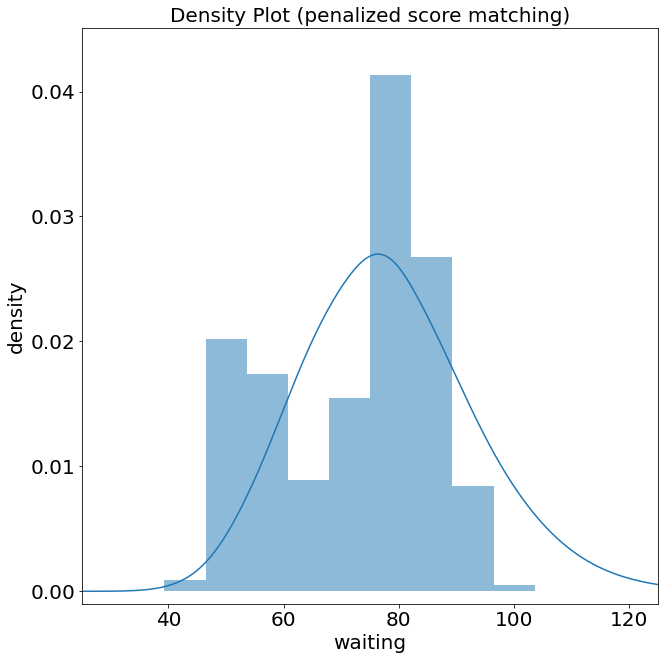

**************************************************
log penalty = -5.0


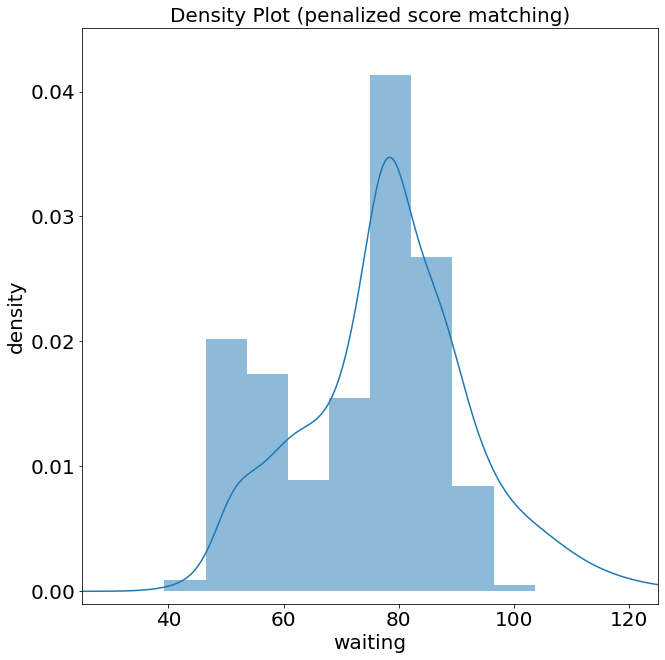

**************************************************
log penalty = -7.0


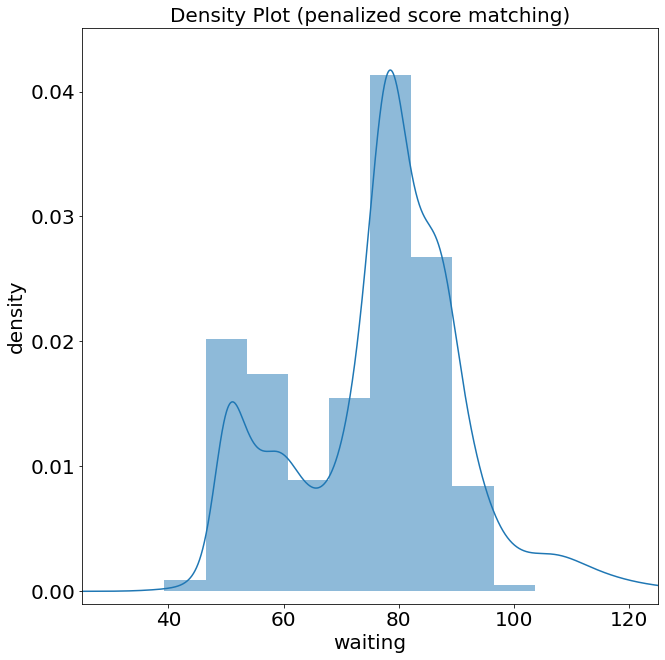

**************************************************
log penalty = -9.0


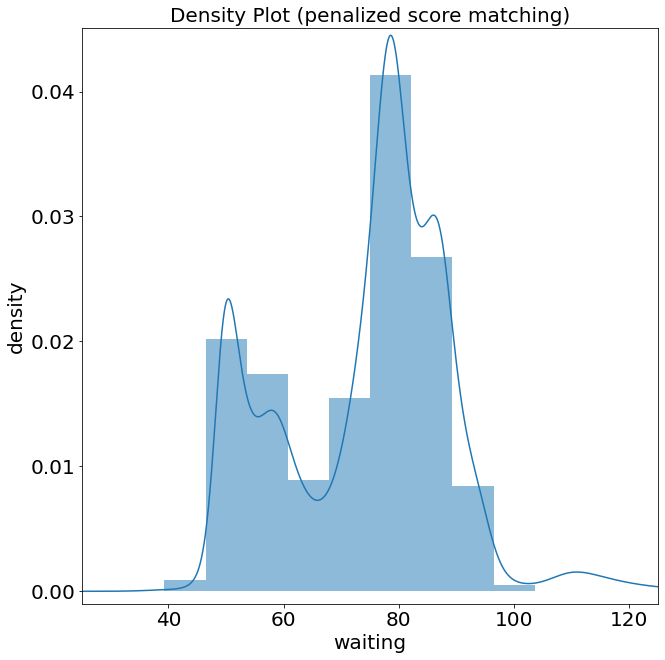

**************************************************
log penalty = -10.5


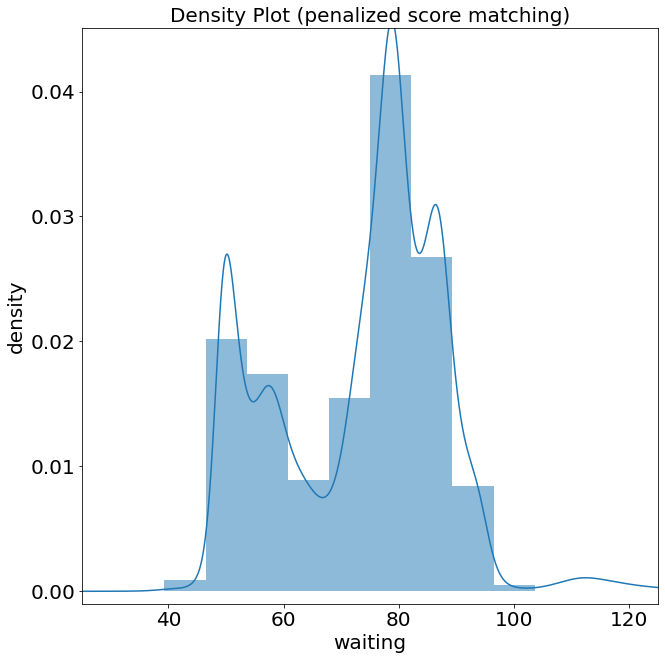

**************************************************
log penalty = -12.0


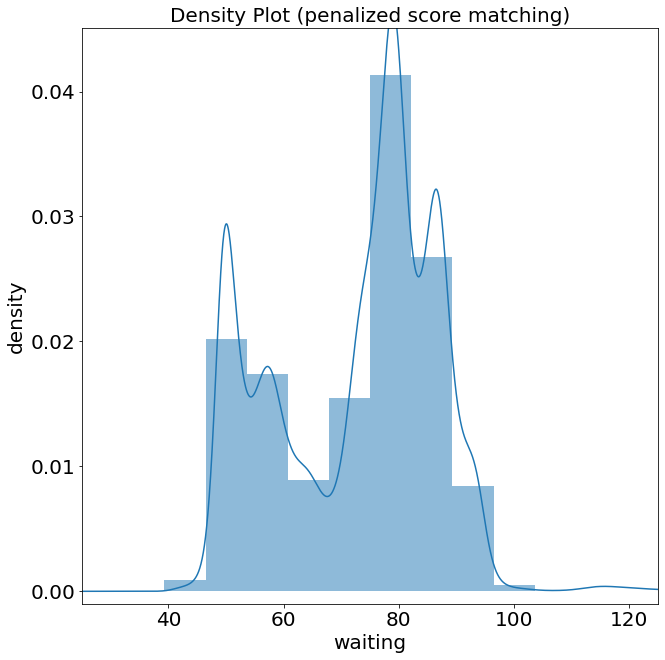

In [15]:
log_penalty_param_list = [-2., -5., -7., -9., -10.5, -12.] 
# np.arange(-10., -7., 0.5) # np.arange(-12., 0.5, 0.5)

for log_pen_param in log_penalty_param_list: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    coef_smpen = sm_pen1.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param))
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting.reshape(-1, 1), 
        kernel_function = sm_pen1.kernel_function_gridpoints, 
        base_density = base_density1, 
        basis_type = 'grid_points', 
        coef = coef_smpen, 
        normalizing = True, 
        method = 'penalized score matching', 
        x_label = 'waiting',
        grid_points = grid_points,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    file_name_coef = f'/baseden={base_density1.a}-{base_density1.scale}-logpenparam={log_pen_param}-coef.npy'
    np.save(sm_folder + file_name_coef, coef_smpen)

    file_name_den = f'/baseden={base_density1.a}-{base_density1.scale}-logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(sm_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -12.0


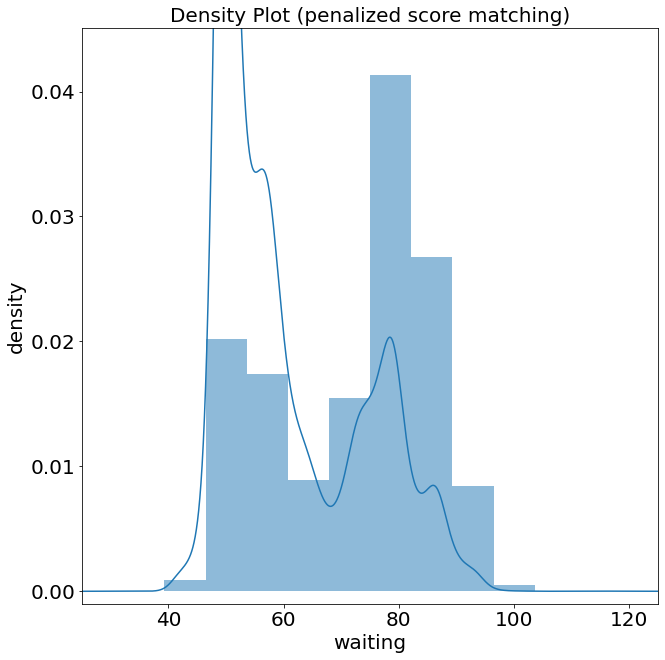

**************************************************
log penalty = -10.5


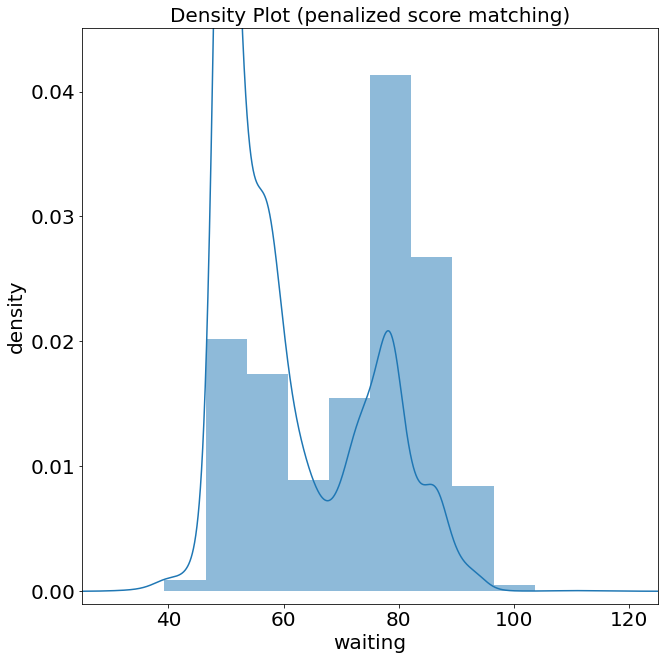

**************************************************
log penalty = -9.0


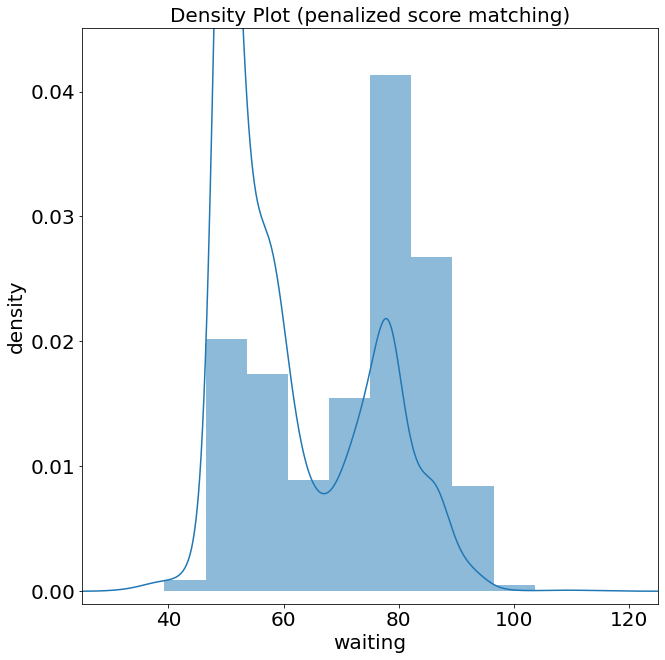

**************************************************
log penalty = -7.0


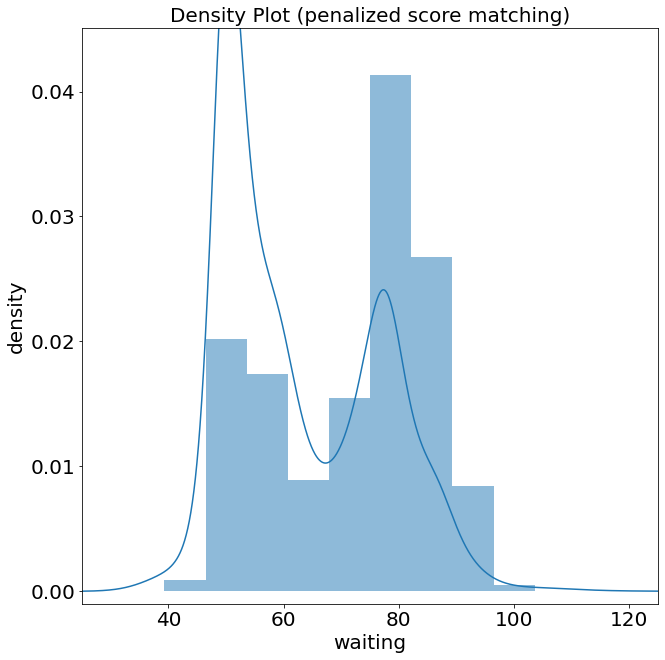

**************************************************
log penalty = -5.0


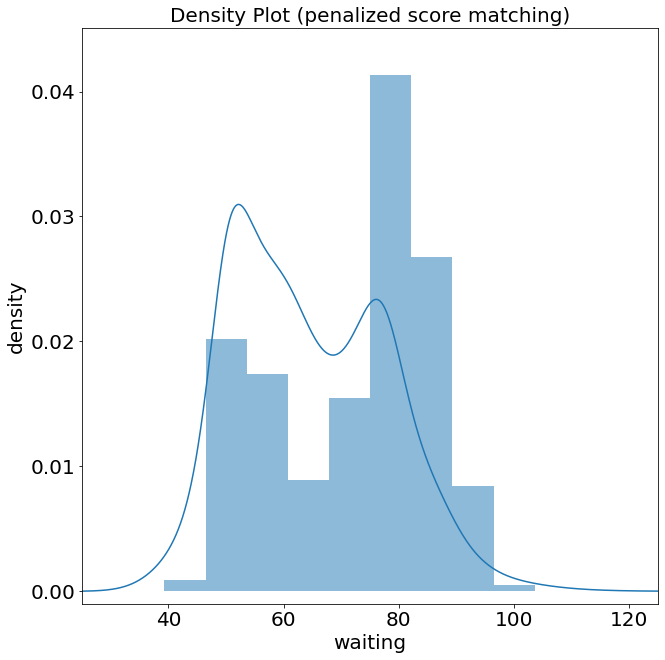

**************************************************
log penalty = -2.0


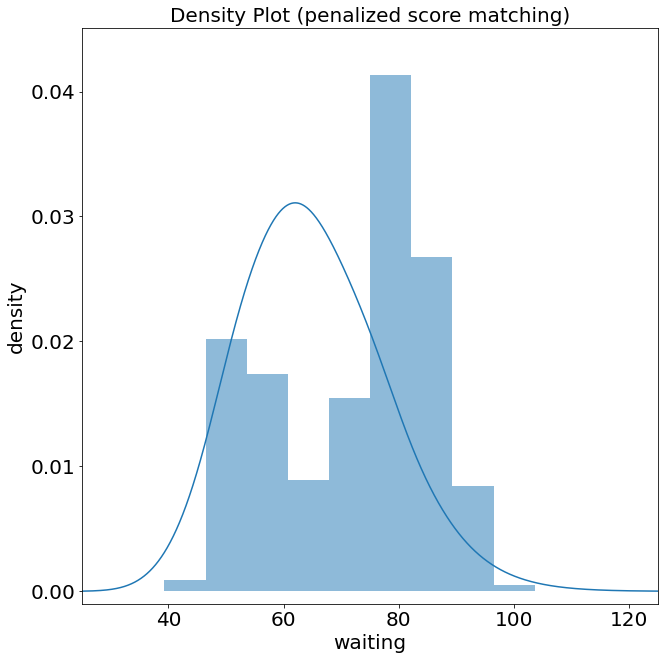

In [63]:
log_penalty_param_list = [-2., -5., -7., -9., -10.5, -12.] 
# np.arange(-10., -7., 0.5) # np.arange(-12., 0.5, 0.5)

for log_pen_param in log_penalty_param_list[::-1]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    coef_smpen = sm_pen2.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param))
    
#     if log_pen_param < -6.: 
#         coef_smpen[:65] = coef_smpen[:65] * 0.98
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting.reshape(-1, 1), 
        kernel_function = sm_pen2.kernel_function_gridpoints, 
        base_density = base_density2, 
        basis_type = 'grid_points', 
        coef = coef_smpen, 
        normalizing = True, 
        method = 'penalized score matching', 
        x_label = 'waiting',
        grid_points = grid_points,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
#     file_name_coef = f'/baseden={base_density2.a}-{base_density2.scale}-logpenparam={log_pen_param}-coef.npy'
#     np.save(sm_folder + file_name_coef, coef_smpen)

#     file_name_den = f'/baseden={base_density2.a}-{base_density2.scale}-logpenparam={log_pen_param}-densityvals-newdata.npy'
#     np.save(sm_folder + file_name_den, den_vals['den_vals'])
    